In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define Paths
RAW_DATA_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"

# Checking
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Directories set up. \nRaw Data: {os.path.abspath(RAW_DATA_DIR)}\nProcessed Data: {os.path.abspath(PROCESSED_DIR)}")

Directories set up. 
Raw Data: c:\Users\kavee\Music\IntWiz.3.0\data\raw
Processed Data: c:\Users\kavee\Music\IntWiz.3.0\data\processed


In [4]:
# Standardized Emotion Map
EMOTION_MAP = {
    'neutral': 'neutral',
    'calm': 'neutral',      # Merge Calm -> Neutral
    'happy': 'happy',
    'sad': 'sad',
    'angry': 'angry',
    'fear': 'fearful',      # Standardize 'fear' to 'fearful'
    'fearful': 'fearful',
    'disgust': 'disgust',
    'surprise': 'surprised',
    'surprised': 'surprised',
    'ps': 'surprised'       # TESS 'pleasant surprise' -> surprised
}

print("Emotion Map Configured.")

Emotion Map Configured.


In [5]:
# Parse Ravdess
def parse_ravdess(path):
    files = []
    # 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised
    ravdess_codes = {
        '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
        '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
    }
    
    for root, _, filenames in os.walk(path):
        for file in filenames:
            if file.endswith(".wav"):
                parts = file.split("-")
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = ravdess_codes.get(emotion_code)
                    if emotion:
                        files.append([os.path.join(root, file), emotion, 'RAVDESS'])
    return files

# Execute
ravdess_data = parse_ravdess(os.path.join(RAW_DATA_DIR, "RAVDESS"))
print(f"RAVDESS Files Found: {len(ravdess_data)}")

RAVDESS Files Found: 1440


In [6]:
# Parse CREMA-D
def parse_crema(path):
    files = []
    crema_codes = {
        'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fearful',
        'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad'
    }
    
    # CREMA-D is usually a flat folder, no subdirectories
    if os.path.exists(path):
        for file in os.listdir(path):
            if file.endswith(".wav"):
                parts = file.split("_")
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = crema_codes.get(emotion_code)
                    if emotion:
                        files.append([os.path.join(path, file), emotion, 'CREMA-D'])
    return files

# Execute
crema_data = parse_crema(os.path.join(RAW_DATA_DIR, "CREMA-D"))
print(f"CREMA-D Files Found: {len(crema_data)}")

CREMA-D Files Found: 7442


In [7]:
# Parse TESS
def parse_tess(path):
    files = []
    if os.path.exists(path):
        for root, _, filenames in os.walk(path):
            for file in filenames:
                if file.endswith(".wav"):
                    # TESS filename format: OAF_back_fear.wav or YAF_voice_happy.wav
                    # The emotion is usually the last word before .wav
                    parts = file.replace(".wav", "").split("_")
                    emotion_raw = parts[-1].lower()
                    
                    # Manual fix for 'ps' (pleasant surprise)
                    if emotion_raw == 'ps': emotion_raw = 'ps'

                    # Only add if it maps to something in our system
                    if emotion_raw in EMOTION_MAP or emotion_raw == 'ps':
                         files.append([os.path.join(root, file), emotion_raw, 'TESS'])
    return files

# Execute
tess_data = parse_tess(os.path.join(RAW_DATA_DIR, "TESS"))
print(f"TESS Files Found: {len(tess_data)}")

TESS Files Found: 2800


In [8]:
# Parse SAVEE
def parse_savee(path):
    files = []
    savee_codes = {
        'a': 'angry', 'd': 'disgust', 'f': 'fearful',
        'h': 'happy', 'n': 'neutral', 'sa': 'sad', 'su': 'surprised'
    }
    
    if os.path.exists(path):
        for file in os.listdir(path):
            if file.endswith(".wav"):
                # Filename is usually DC_a01.wav or just a01.wav
                # We need the letters part of the filename
                filename = file.split("_")[-1] # Grab last part if there's an underscore
                code = ""
                for char in filename:
                    if char.isalpha():
                        code += char
                    else:
                        break
                
                emotion = savee_codes.get(code)
                if emotion:
                    files.append([os.path.join(path, file), emotion, 'SAVEE'])
    return files

# Execute
savee_data = parse_savee(os.path.join(RAW_DATA_DIR, "SAVEE"))
print(f"SAVEE Files Found: {len(savee_data)}")

SAVEE Files Found: 480


In [9]:
# Combine all lists
all_data = ravdess_data + crema_data + tess_data + savee_data

# Create DataFrame
df = pd.DataFrame(all_data, columns=['path', 'source_emotion', 'dataset'])

# Apply the Standard Map
df['emotion'] = df['source_emotion'].map(EMOTION_MAP)

# Drop missing values (if any emotion didn't map correctly)
df.dropna(subset=['emotion'], inplace=True)

# Shuffle the dataset
df = df.sample(frac=1).reset_index(drop=True)

print(f"Total Files: {len(df)}")
print("\nEmotion Counts:")
print(df['emotion'].value_counts())

Total Files: 12162

Emotion Counts:
emotion
sad          1923
angry        1923
fearful      1923
disgust      1923
happy        1923
neutral      1895
surprised     652
Name: count, dtype: int64


✅ Metadata saved to: ../data/processed\metadata.csv


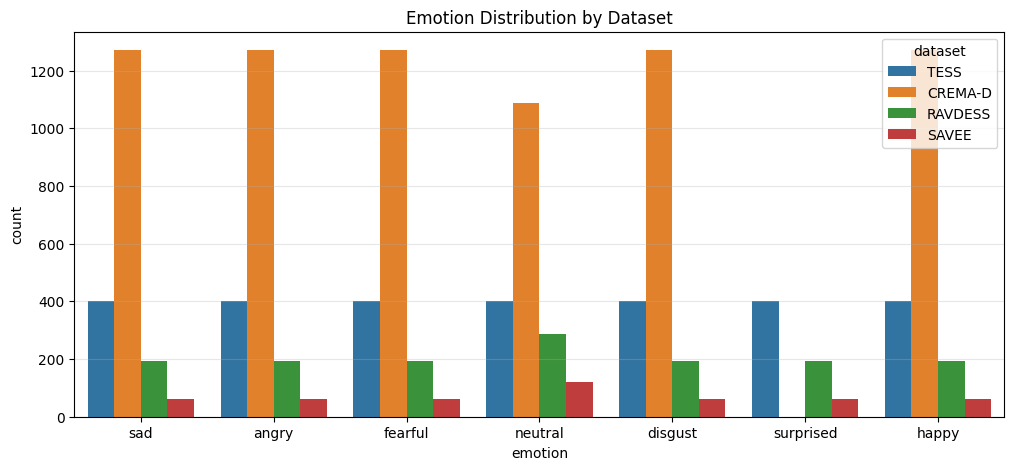

In [10]:
# Save to CSV
output_path = os.path.join(PROCESSED_DIR, "metadata.csv")
df.to_csv(output_path, index=False)
print(f"✅ Metadata saved to: {output_path}")

# Plot
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='emotion', hue='dataset')
plt.title("Emotion Distribution by Dataset")
plt.grid(axis='y', alpha=0.3)
plt.show()